#  **``LFPy``**

In [5]:
#================================================================================
#= Import
#================================================================================
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#================================================================================
#= Controls
#================================================================================

# NameError: name 'cell_indices_to_plot' is not defined
# cell_indices_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] # Specify cell indices to plot in 'plotsomavs' - 
# Note: plotting too many cells can randomly cause TCP connection errors
# cell_indices_to_plot = range(0, 40, 5)
# cell_indices_to_plot = [0, 1, 800, 801, 850, 851, 920, 921]
# N_cells = 1000

circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)
N_HL23PYR = circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PYR']
N_HL23SST = circuit_params['SING_CELL_PARAM'].at['cell_num','HL23SST']
N_HL23PV = circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PV']
N_HL23VIP = circuit_params['SING_CELL_PARAM'].at['cell_num','HL23VIP']

N_cells = N_HL23PYR + N_HL23SST + N_HL23PV + N_HL23VIP

cell_indices_to_plot = [0, 1, N_HL23PYR, N_HL23PYR + 1, N_HL23PYR + N_HL23SST, N_HL23PYR + N_HL23SST + 1, N_HL23PYR + N_HL23SST + N_HL23PV, N_HL23PYR + N_HL23SST + N_HL23PV + 1]

#================================================================================
#= Plotting
#================================================================================
#===============================np.mim(allY)
#= Frank
#===============================
pop_colors = {'HL23PYR':'k', 'HL23SST':'red', 'HL23PV':'green', 'HL23VIP':'yellow'}
popnames = ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']
#===============================

#===============================
#= Alex
#===============================
pop_colors = {'HL23PYR':'k', 'HL23SST':'crimson', 'HL23PV':'green', 'HL23VIP':'darkorange'}
popnames = ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']
poplabels = ['PN', 'MN', 'BN', 'VN']

font = {'family' : 'normal',
		'weight' : 'normal',
		'size'   : 14}

-1499.4521162035744 -550.1588014778564


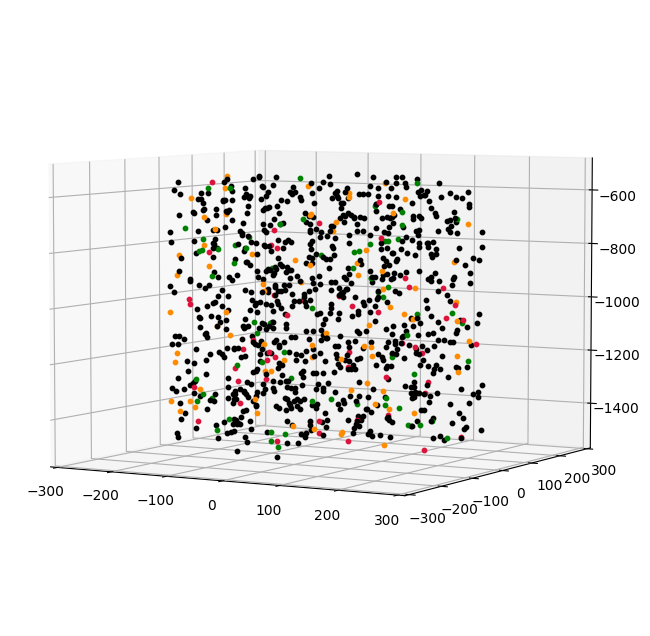

In [7]:
# Plot soma positions
def plot_network_somas(OUTPUTPATH):
	filename = os.path.join(OUTPUTPATH,'cell_positions_and_rotations.h5')
	popDataArray = {}
	popDataArray[popnames[0]] = pd.read_hdf(filename,popnames[0])
	popDataArray[popnames[0]] = popDataArray[popnames[0]].sort_values('gid')
	popDataArray[popnames[1]] = pd.read_hdf(filename,popnames[1])
	popDataArray[popnames[1]] = popDataArray[popnames[1]].sort_values('gid')
	popDataArray[popnames[2]] = pd.read_hdf(filename,popnames[2])
	popDataArray[popnames[2]] = popDataArray[popnames[2]].sort_values('gid')
	popDataArray[popnames[3]] = pd.read_hdf(filename,popnames[3])
	popDataArray[popnames[3]] = popDataArray[popnames[3]].sort_values('gid')

	fig = plt.figure(figsize=(8, 8))
	ax = fig.add_subplot(111, projection='3d')
	ax.view_init(elev=5)
	allY = []
	for pop in popnames:
		for i in range(0,len(popDataArray[pop]['gid'])):
			ax.scatter(popDataArray[pop]['x'][i],popDataArray[pop]['y'][i],popDataArray[pop]['z'][i], c=pop_colors[pop], s=10)
			ax.set_xlim([-300, 300])
			ax.set_ylim([-300, 300])
			allY.append(popDataArray[pop]['z'][i])
			# ax.set_zlim([-1200, -400])
	print(np.min(allY),np.max(allY))
	return fig

OUTPUTPATH = "Circuit_output/"
fig = plot_network_somas(OUTPUTPATH)

In [3]:
import h5py

filename = os.path.join(OUTPUTPATH,'synapse_connections.h5')

f = h5py.File(filename, 'r')

In [17]:
f.keys()

<KeysViewHDF5 ['HL23PV:HL23PV', 'HL23PV:HL23PYR', 'HL23PV:HL23SST', 'HL23PV:HL23VIP', 'HL23PYR:HL23PV', 'HL23PYR:HL23PYR', 'HL23PYR:HL23SST', 'HL23PYR:HL23VIP', 'HL23SST:HL23PV', 'HL23SST:HL23PYR', 'HL23SST:HL23SST', 'HL23SST:HL23VIP', 'HL23VIP:HL23PV', 'HL23VIP:HL23PYR', 'HL23VIP:HL23SST', 'HL23VIP:HL23VIP', 'synparams']>

In [4]:
# save_connections : bool
#         [('gid_pre'), ('gid', 'i8'), ('weight', 'f8'), ('delay', 'f8'),
#         ('sec', 'U64'), ('sec.x', 'f8'),
#         ('x', 'f8'), ('y', 'f8'), ('z', 'f8')],

# where gid_pre is presynapic cell id, gid is postsynaptic cell id, weight connection weight, 
# delay connection delay, sec section name, sec.x relative location on section, 
# and x, y, z the corresponding midpoint coordinates of the target segment.

In [ ]:
pop_colors = {'HL23PYR':'k', 'HL23SST':'crimson', 'HL23PV':'green', 'HL23VIP':'darkorange'}

In [21]:
N_HL23PYR = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PYR'])
N_HL23SST = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23SST'])
N_HL23PV = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PV'])
N_HL23VIP = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23VIP'])

cellNumber = {}
cellNumber['HL23PYR'] = N_HL23PYR
cellNumber['HL23SST'] = N_HL23SST
cellNumber['HL23PV'] = N_HL23PV
cellNumber['HL23VIP'] = N_HL23VIP

cellNumber0 = {}
cellNumber0['HL23PYR'] = 0
cellNumber0['HL23SST'] = N_HL23PYR
cellNumber0['HL23PV'] = N_HL23PYR + N_HL23SST
cellNumber0['HL23VIP'] = N_HL23PYR + N_HL23SST + N_HL23PV
cellNumber0

{'HL23PYR': 0, 'HL23SST': 800, 'HL23PV': 850, 'HL23VIP': 920}

In [22]:
for pre in popnames:
    for post in popnames:

        if pre+':'+post in f.keys():

            pc2pc = []
            synloc2 = {}
            synsec2 = {}
            matrix = {}
            for i in range(cellNumber[post]):
                matrix[i] = [] 
                synloc2[i] = [] 
                synsec2[i] = []  

            for vec in list(f[pre+':'+post]):
                gid_pre,  gid , weight, delay, sec, secx, x, y, z = vec
                section = str(sec).split(".")[1].split("[")[0] + "_" + str(sec).split(".")[1].split("[")[1][:-2]
                # print(section+"_"+str(secx))
                synsec2[gid-cellNumber0[post]].append(section)
                synloc2[gid-cellNumber0[post]].append(secx)
                matrix[gid-cellNumber0[post]].append([gid_pre-cellNumber0[pre],gid-cellNumber0[post]])

            pre2post = []
            synloc = []
            synsec = []
            for i in range(cellNumber[post]):
                for j,conn in enumerate(matrix[i]):
                    pre2post.append(conn)
                    synsec.append(synsec2[i][j])
                    synloc.append(synloc2[i][j])

            print(pre+':'+post, len(pre2post),len(synloc),len(synsec))

HL23PYR:HL23PYR 288579 288579 288579
HL23PYR:HL23SST 61376 61376 61376
HL23PYR:HL23PV 40304 40304 40304
HL23PYR:HL23VIP 22876 22876 22876
HL23SST:HL23PYR 91428 91428 91428
HL23SST:HL23SST 1260 1260 1260
HL23SST:HL23PV 8931 8931 8931
HL23SST:HL23VIP 1105 1105 1105
HL23PV:HL23PYR 91018 91018 91018
HL23PV:HL23SST 3120 3120 3120
HL23PV:HL23PV 26595 26595 26595
HL23PV:HL23VIP 1260 1260 1260
HL23VIP:HL23PYR 0 0 0
HL23VIP:HL23SST 12852 12852 12852
HL23VIP:HL23PV 6006 6006 6006
HL23VIP:HL23VIP 2296 2296 2296


In [ ]:
# pc2pc = []
# synloc2 = {}
# synsec2 = {}
# matrix = {}
# for i in range(800):
#     matrix[i] = [] 
#     synloc2[i] = [] 
#     synsec2[i] = []  

# for vec in list(f['HL23PYR:HL23PYR']):
#     gid_pre,  gid , weight, delay, sec, secx, x, y, z = vec
#     section = str(sec).split(".")[1].split("[")[0] + "_" + str(sec).split(".")[1].split("[")[1][:-2]
#     # print(section+"_"+str(secx))
#     synsec2[gid].append(section)
#     synloc2[gid].append(secx)
#     matrix[gid].append([gid_pre,gid])

# for idx in range(0,800,40):
#     pc2pc = []
#     synloc = []
#     synsec = []
#     for i in range(idx,idx+40):
#         for j,conn in enumerate(matrix[i]):
#             pc2pc.append(conn)
#             synsec.append(synsec2[i][j])
#             synloc.append(synloc2[i][j])

In [31]:
pre2post[::1000],synloc[::1000],synsec[::1000]

([[6, 0], [16, 34], [10, 68]],
 [0.1, 0.5, 0.7857142857142857],
 ['dend_41', 'dend_24', 'dend_32'])

In [27]:
len(pre2post),len(synloc),len(synsec)

(2296, 2296, 2296)

In [85]:
a, b = np.unique(preS,return_counts=True)
np.unique(b,return_counts=True)

(array([279, 282, 285, 288, 291, 297, 300, 303, 306, 309, 312, 315, 318,
        321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357,
        360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396,
        399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435,
        438, 441, 444, 447, 453, 468]),
 array([ 1,  1,  1,  3,  3,  2,  3,  3,  4,  5,  8, 10, 12, 12, 14, 16, 20,
        21, 26, 21, 28, 44, 25, 31, 33, 32, 39, 36, 42, 33, 26, 22, 30, 21,
        30, 18, 16, 15,  8, 16, 15, 11,  4,  5,  4,  4,  8,  1,  2,  1,  3,
         1,  1,  2,  3,  2,  1,  1]))

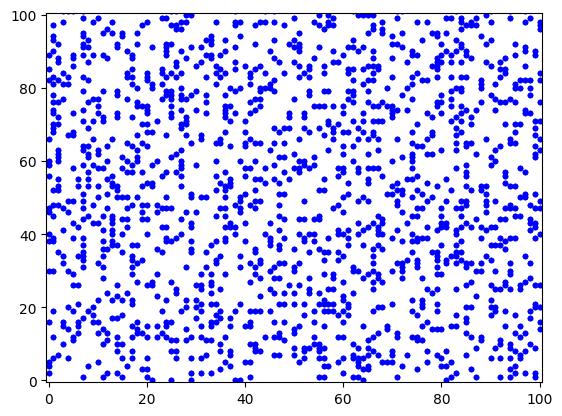

In [89]:
plt.plot(preS, postS, '.b')
plt.xlim(-0.5,100.5)
plt.ylim(-0.5,100.5);

In [99]:
a, b = np.unique(poststr[:3000], return_counts=True)

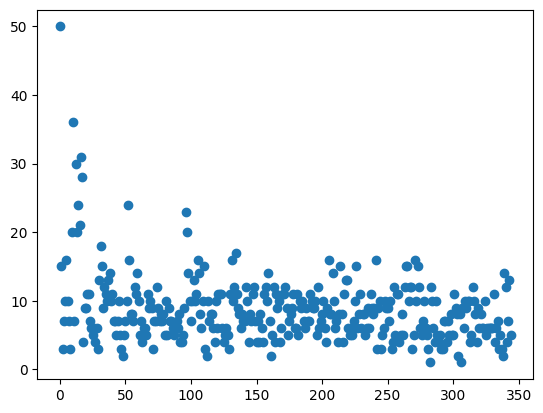

In [100]:
plt.plot(b, 'o')

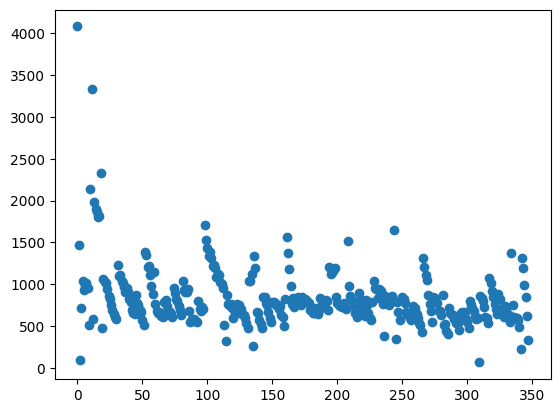

In [87]:
plt.plot(b, 'o')

In [1]:
#===========================================================================
# Import, Set up MPI Variables, Load Necessary Files
#===========================================================================
from mpi4py import MPI
import time
tic_0 = time.perf_counter() #script runtime calculation value
import os
from os.path import join
import sys
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
from scipy import stats as st
import neuron
from neuron import h, gui
import LFPy
from LFPy import NetworkCell, Network, Synapse, RecExtElectrode, StimIntElectrode
from matplotlib.collections import PolyCollection
import matplotlib.pyplot as plt
import pandas as pd

#MPI variables:
COMM = MPI.COMM_WORLD
SIZE = COMM.Get_size()
RANK = COMM.Get_rank()
GLOBALSEED = 1234

# Create new RandomState for each RANK
SEED = GLOBALSEED*10000
np.random.seed(SEED + RANK)
local_state = np.random.RandomState(SEED + RANK)
halfnorm_rv = st.halfnorm
halfnorm_rv.random_state = local_state
uniform_rv = st.uniform
uniform_rv.random_state = local_state
#from net_params import *

#Mechanisms and files
print('Mechanisms found: ', os.path.isfile('mod/x86_64/special')) if RANK==0 else None
neuron.h('forall delete_section()')
neuron.load_mechanisms('mod/')
h.load_file('net_functions.hoc')
#===========================================================================
# Simulation, Analysis, and Plotting Controls
#===========================================================================
TESTING = True # i.e.g generate 1 cell/pop, with 0.1 s runtime
no_connectivity = False

stimulate = False # Add a stimulus
MDD = False #decrease PN GtonicApic and MN2PN weight by 40%
DRUG = False

rec_LFP = False #record LFP from center of layer
rec_DIPOLES = False #record population - wide dipoles

run_circuit_functions = True
#===========================================================================
# Params
#===========================================================================
dt = 0.025 #for both cell and network
tstart = 0.
tstop = 10000.
celsius = 34.
v_init = -80. #for both cell and network

###################### Load and organize Excel file ################################
circuit_params = {}

#Import Excel file
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)

#Get cell names and import biophys
cell_names = [i for i in circuit_params['conn_probs'].axes[0]]
for name in cell_names:
    h.load_file('models/biophys_'+name+'.hoc')

circuit_params["syn_params"] = {'none':{'tau_r_AMPA': 0,'tau_d_AMPA': 0,'tau_r_NMDA': 0,
                                'tau_d_NMDA': 0, 'e': 0,'Dep': 0,'Fac': 0,'Use': 0,'u0':0,'gmax': 0}}
circuit_params["multi_syns"] = {'none':{'loc':0,'scale':0}}
# organizing dictionary for LFPY input
for pre in cell_names:
    for post in cell_names:
        if "PYR" in pre:
            circuit_params["syn_params"][pre+post] = {'tau_r_AMPA': 0.3, 'tau_d_AMPA': 3, 'tau_r_NMDA': 2,
                                                      'tau_d_NMDA': 65, 'e': 0, 'u0':0,
                                                      'Dep': circuit_params["Depression"].at[pre, post],
                                                      'Fac': circuit_params["Facilitation"].at[pre, post],
                                                      'Use': circuit_params["Use"].at[pre, post],
                                                      'gmax': circuit_params["syn_cond"].at[pre, post]}
        else:
            circuit_params["syn_params"][pre+post] = {'tau_r': 1, 'tau_d': 10, 'e': -80, 'u0':0,
                                                      'Dep': circuit_params["Depression"].at[pre, post],
                                                      'Fac': circuit_params["Facilitation"].at[pre, post],
                                                      'Use': circuit_params["Use"].at[pre, post],
                                                      'gmax': circuit_params["syn_cond"].at[pre, post]}
        circuit_params["multi_syns"][pre+post] = {'loc':int(circuit_params["n_cont"].at[pre, post]),'scale':0}


stimuli = []
for stimulus in circuit_params['STIM_PARAM'].axes[0]:
    stimuli.append({})
    for param_name in circuit_params['STIM_PARAM'].axes[1]:
        stimuli[-1][param_name] = circuit_params['STIM_PARAM'].at[stimulus, param_name]
    new_param = circuit_params["syn_params"][stimuli[-1]['syn_params']].copy()
    new_param['gmax'] = stimuli[-1]['gmax']
    stimuli[-1]['new_param'] = new_param
COMM.Barrier()
print('Importing, setting up MPI variables and loading necessary files took ', str((time.perf_counter() - tic_0)/60)[:5], 'minutes') if RANK==0 else None
#################################################################################
if TESTING:
    OUTPUTPATH = 'Circuit_output_testing'
    for name in cell_names:
        circuit_params['SING_CELL_PARAM'].at['cell_num',name] = 1
    tstop = 100
    print('Running test...') if RANK ==0 else None

else:
    OUTPUTPATH = 'Circuit_output'
    print('Running full simulation...') if RANK==0 else None

COMM.Barrier()
##################################################################################
networkParams = {
        'dt' : dt,
        'tstart': tstart,
        'tstop' : tstop,
        'v_init' : v_init,
        'celsius' : celsius,
        'OUTPUTPATH' : OUTPUTPATH,
        'verbose': False}

#              L2/3   L4     L5
PYRmaxApics = [550   ,1550   ,1900]
uppers =      [-250  ,-1200 ,-1600]
lowers =      [-1200 ,-1580 ,-2300]

depths = []
rangedepths = []
minSynLocs = []
syn_pos = []
pop_args = {}

for i in range (3):
    depths.append((lowers[i]-uppers[i])/2-PYRmaxApics[i])
    rangedepths.append(abs(lowers[i]-uppers[i])/2)
    minSynLocs.append((lowers[i]-uppers[i])/2*3-PYRmaxApics[i])

    syn_pos.append({'section' : ['apic', 'dend'],
                    'fun' : [uniform_rv, halfnorm_rv],
                    'funargs' : [{'loc':minSynLocs[i], 'scale':abs(minSynLocs[i])},{'loc':minSynLocs[i], 'scale':abs(minSynLocs[i])}],
                    'funweights' : [1, 1.]})
    syn_pos.append({'section' : ['apic'],
                    'fun' : [uniform_rv],
                    'funargs' : [{'loc':minSynLocs[i], 'scale':abs(minSynLocs[i])}],
                    'funweights' : [1.]})
    syn_pos.append({'section' : ['dend'],
                    'fun' : [uniform_rv],
                    'funargs' : [{'loc':minSynLocs[i], 'scale':abs(minSynLocs[i])}],
                    'funweights' : [1.]})
    syn_pos.append({'section' : ['dend'],
                   'fun' : [halfnorm_rv],
                   'funargs' : [{'loc':minSynLocs[i], 'scale':abs(minSynLocs[i])}],
                   'funweights' : [1.]})
    names = ['HL2','HL4','HL5']
    pop_args[names[i]]={'radius':250,
                        'loc':depths[i],
                        'scale':rangedepths[i]*4,
                        'cap':rangedepths[i]}

# class RecExtElectrode parameters:
L23_size = abs(uppers[1] - lowers[1])
e1 = 5 #-725

LFPelectrodeParameters = dict(
        x=np.zeros(1),
        y=np.zeros(1),
        z=[e1],
        N=np.array([[0., 1., 0.] for _ in range(1)]),
        r=5.,
        n=50,
        sigma=0.3,
        method="soma_as_point")


#method Network.simulate() parameters

simargs = {'rec_imem': False,
           'rec_vmem': False,
           'rec_ipas': False,
           'rec_icap': False,
           'rec_isyn': False,
           'rec_vmemsyn': False,
           'rec_istim': False,
           'rec_current_dipole_moment':rec_DIPOLES,
           'rec_pop_contributions': False,
           'rec_variables': [],
           'to_memory': True,
           'to_file': False,
           'file_name':'OUTPUT.h5',
           'dotprodcoeffs': None}

#===========================================================================
# Functions
#===========================================================================
def generateSubPop(popsize,mname,popargs,Gou,Gtonic,GtonicApic):
    print('Initiating ' + mname + ' population...') if RANK==0 else None
    morphpath = 'morphologies/' + mname + '.swc'
    templatepath = 'models/NeuronTemplate.hoc'
    templatename = 'NeuronTemplate'
    pt3d = True
    cellParams = {
            'morphology': morphpath,
            'templatefile': templatepath,
            'templatename': templatename,
            'templateargs': morphpath,
            'v_init': v_init, #initial membrane potential, d=-65
            'passive': False,#initialize passive mechs, d=T, should be overwritten by biophys
            'dt': dt,
            'tstart': 0.,
            'tstop': tstop,#defaults to 100
            'nsegs_method': None,
            'pt3d': pt3d,#use pt3d-info of the cell geometries switch, d=F
            'delete_sections': False,
            'verbose': False}#verbose output switch, for some reason doens't work, figure out why}

    
    rotation = {'x':circuit_params['SING_CELL_PARAM'].at['rotate_x', mname],'y':circuit_params['SING_CELL_PARAM'].at['rotate_y', mname]}

    popParams = {
            'CWD': None,
            'CELLPATH': None,
            'Cell' : LFPy.NetworkCell, #play around with this, maybe put popargs into here
            'POP_SIZE': int(popsize),
            'name': mname,
            'cell_args' : {**cellParams},
            'pop_args' : popargs,
            'rotation_args' : rotation}

    network.create_population(**popParams)

    # Add biophys, OU processes, & tonic inhibition to cells
    for cellind in range(0,len(network.populations[mname].cells)):
        rseed = int(local_state.uniform()*SEED)
        biophys = 'h.biophys_' + mname + '(network.populations[\'' + mname + '\'].cells[' + str(cellind) + '].template)'
        exec(biophys)
        if 'PYR' in mname and cellind == 0:
        # if 'PYR' in mname and rseed == 7313766:  # compare with NetPyNE
            h.createArtificialSyn(rseed,network.populations[mname].cells[cellind].template,Gou)
            h.addTonicInhibition(network.populations[mname].cells[cellind].template,Gtonic,GtonicApic)

# HL23PYR 0 7313766
# HL23PYR 0 4406331
# HL23PYR 0 6649282
# HL23PV 0 8984541
# HL23VIP 0 10237329
# HL23VIP 0 10344818
# HL23SST 0 5429614
# HL23SST 0 7285414
# HL23SST 0 10423057
# HL23PV 0 9819257
# HL23PV 0 5059734
# HL23VIP 0 9256009

def addStimulus():
    cell_nums=[circuit_params['SING_CELL_PARAM'].at['cell_num',name] for name in cell_names]
    for stim in stimuli:
        stim_index = sum(cell_nums[:cell_names.index(stim['cell_name'])]) + stim['num_cells'] + stim['start_index']
        for gid, cell in zip(network.populations[stim['cell_name']].gids, network.populations[stim['cell_name']].cells):
            if gid < stim_index and gid >= sum(cell_nums[:cell_names.index(stim['cell_name'])]) + stim['start_index']:
                idx = cell.get_rand_idx_area_norm(section=stim['loc'], nidx=stim['loc_num'])
                for i in idx:
                    time_d=0
                    syn = Synapse(cell=cell, idx=i, syntype=stim['stim_type'], weight=1,**stim['new_param'])
                    while time_d <= 0:
                        time_d = np.random.uniform(low = stim['delay'], high = stim['delay']+stim['delay_range'])
                    syn.set_spike_times_w_netstim(noise=0, start=(stim['start_time']+time_d), number=stim['num_stim'], interval=stim['interval'], seed=GLOBALSEED)
#===========================================================================
# Sim
#===========================================================================
network = Network(**networkParams)

if MDD:
    # synaptic reduction
    for pre in cell_names:
        for post in cell_names:
            if 'SST' in pre:
                circuit_params["syn_params"][pre+post]["gmax"] = circuit_params["syn_cond"].at[pre, post]*0.6 # Synaptic reduction
    # tonic reduction
    for post in cell_names:
        if 'PYR' in post:
            circuit_params['SING_CELL_PARAM'].at['apic_tonic',post] = circuit_params['SING_CELL_PARAM'].at['apic_tonic',post]*0.6
            circuit_params['SING_CELL_PARAM'].at["drug_apic_tonic",post] = circuit_params['SING_CELL_PARAM'].at["drug_apic_tonic",post]*0.6
        else:
            sst = 0
            total = 0
            for pre in cell_names:
                if 'SST' in pre:
                    sst += circuit_params["syn_cond"].at[pre, post]*circuit_params["n_cont"].at[pre,post]*circuit_params["conn_probs"].at[pre, post]
                    total += circuit_params["syn_cond"].at[pre, post]*circuit_params["n_cont"].at[pre,post]*circuit_params["conn_probs"].at[pre, post]
                elif 'PV' in pre or 'VIP' in pre:
                    total += circuit_params["syn_cond"].at[pre, post]*circuit_params["n_cont"].at[pre, post]*circuit_params["conn_probs"].at[pre, post]
            circuit_params['SING_CELL_PARAM'].at['norm_tonic',post] -= circuit_params['SING_CELL_PARAM'].at['norm_tonic',post]*sst/total*0.4
            print(post, '_tonic reduced by: ', sst/total*100*0.4, '%') if RANK == 0 else None

# Generate Populations
tic = time.perf_counter()

for cell_name in cell_names:
    if DRUG:
        generateSubPop(circuit_params['SING_CELL_PARAM'].at['cell_num',cell_name],
                       cell_name,pop_args[cell_name[:3]],
                       circuit_params['SING_CELL_PARAM'].at['GOU',cell_name],
                       circuit_params['SING_CELL_PARAM'].at['drug_tonic',cell_name],
                       circuit_params['SING_CELL_PARAM'].at['drug_apic_tonic',cell_name])
    else:
        generateSubPop(circuit_params['SING_CELL_PARAM'].at['cell_num',cell_name],
                       cell_name,pop_args[cell_name[:3]],
                       circuit_params['SING_CELL_PARAM'].at['GOU',cell_name],
                       circuit_params['SING_CELL_PARAM'].at['norm_tonic',cell_name],               
                       circuit_params['SING_CELL_PARAM'].at['apic_tonic',cell_name])

COMM.Barrier()

print('Instantiating all populations took ', str((time.perf_counter() - tic_0)/60)[:5], 'minutes') if RANK==0 else None

tic = time.perf_counter()

# Synaptic Connection Parameters
E_syn = neuron.h.ProbAMPANMDA
I_syn = neuron.h.ProbUDFsyn

for i, pre in enumerate(network.population_names):
    for j, post in enumerate(network.population_names):
        connectivity = network.get_connectivity_rand(
                        pre=pre,
                        post=post,
                        connprob=0 if no_connectivity else circuit_params["conn_probs"].at[pre, post])
        (conncount, syncount) = network.connect(
                        pre=pre, post=post,
                        connectivity=connectivity,
                        syntype=E_syn if "PYR" in pre else I_syn,
                        synparams=circuit_params["syn_params"][pre+post],
                        weightfun=local_state.normal,
                        weightargs={'loc':1, 'scale':0},
                        minweight=1,
                        delayfun=local_state.normal,
                        delayargs={'loc':0.5, 'scale':0},
                        mindelay=0.5,
                        multapsefun=local_state.normal,
                        multapseargs=circuit_params["multi_syns"][pre+post],

                        syn_pos_args=syn_pos[circuit_params["Syn_pos"].at[pre,post]])

print('Connecting populations took ', str((time.perf_counter() - tic_0)/60)[:5], 'minutes') if RANK==0 else None

# Setup Extracellular Recording Device
COMM.Barrier()
if stimulate:
    addStimulus()
COMM.Barrier()
# Run Simulation

tic = time.perf_counter()

numprocs=1
Mechanisms found:  True
Importing, setting up MPI variables and loading necessary files took  0.007 minutes
Running test...
Initiating HL23PYR population...
Initiating HL23SST population...
Initiating HL23PV population...
Initiating HL23VIP population...
Instantiating all populations took  0.030 minutes
Connected population HL23PYR to HL23PYR by 0.0 connections and 0.0 synapses
Connected population HL23PYR to HL23SST by 0.0 connections and 0.0 synapses
Connected population HL23PYR to HL23PV by 0.0 connections and 0.0 synapses
Connected population HL23PYR to HL23VIP by 0.0 connections and 0.0 synapses
Connected population HL23SST to HL23PYR by 1.0 connections and 12.0 synapses
Connected population HL23SST to HL23SST by 0.0 connections and 0.0 synapses
Connected population HL23SST to HL23PV by 0.0 connections and 0.0 synapses
Connected population HL23SST to HL23VIP by 0.0 connections and 0.0 synapses
Connected population HL23PV to HL23PYR by 0.0 connections and 0.0 synapses
Co

/home/fernando/anaconda3/envs/p38/lib/python3.8/site-packages/LFPy/network.py:796: UserWarning: argument delayfun=<built-in method normal of numpy.random.mtrand.RandomState object at 0x705c43742240> do not appear scipy.stats.rv_continuous or scipy.stats.rv_discrete like and will be deprecated in the future
  warn(f'argument delayfun={delayfun.__str__()} do not appear ' +
/home/fernando/anaconda3/envs/p38/lib/python3.8/site-packages/LFPy/network.py:865: UserWarning: multapsefun<built-in method normal of numpy.random.mtrand.RandomState object at 0x705c43742240> will be deprecated. Use scipy.stats.rv_continuous or scipy.stats.rv_discrete like methods instead
  warn(f'multapsefun{multapsefun.__str__()} will be ' +


In [30]:
network.populations["HL23PYR"].cells[0].get_pt3d_polygons()[-2]

(array([46.6626037 , 48.50729426, 52.16897711, 55.83066825, 59.49229806,
        63.15398162, 64.99867345, 64.58286362, 62.73820673, 59.02107661,
        55.30400898, 51.58688643, 47.86975065, 46.02509496]),
 array([-1028.29370157, -1027.87421285, -1026.9132704 , -1025.95241789,
        -1024.99146809, -1024.03061729, -1023.61108237, -1021.78276971,
        -1022.20229669, -1022.91937365, -1023.63654763, -1024.35362288,
        -1025.07079295, -1025.49027374]))

In [47]:
network.populations["HL23PYR"].cells[0].template.axon[0](0.0).diam

2.843749208516306

In [3]:
[cell1.get_segment() for cell1 in network.populations["HL23PYR"].cells[0].netconsynapses]

[NeuronTemplate[0].apic[27](0.357143),
 NeuronTemplate[0].apic[6](0.214286),
 NeuronTemplate[0].apic[50](0.785714),
 NeuronTemplate[0].apic[21](0.928571),
 NeuronTemplate[0].apic[19](0.5),
 NeuronTemplate[0].apic[47](0.9),
 NeuronTemplate[0].apic[20](0.5),
 NeuronTemplate[0].apic[37](0.166667),
 NeuronTemplate[0].apic[36](0.5),
 NeuronTemplate[0].apic[26](0.642857),
 NeuronTemplate[0].apic[23](0.214286),
 NeuronTemplate[0].apic[39](0.5)]

In [4]:
[cell1.get_segment() for cell1 in network.populations["HL23SST"].cells[0].netconsynapses]

[NeuronTemplate[10].dend[33](0.1),
 NeuronTemplate[10].dend[27](0.277778),
 NeuronTemplate[10].dend[1](0.0714286),
 NeuronTemplate[10].dend[1](0.214286),
 NeuronTemplate[10].dend[22](0.590909),
 NeuronTemplate[10].dend[28](0.5),
 NeuronTemplate[10].dend[50](0.833333),
 NeuronTemplate[10].dend[27](0.166667),
 NeuronTemplate[10].dend[27](0.388889),
 NeuronTemplate[10].dend[30](0.722222),
 NeuronTemplate[10].dend[54](0.357143),
 NeuronTemplate[10].dend[43](0.166667),
 NeuronTemplate[10].dend[26](0.944444),
 NeuronTemplate[10].dend[23](0.5),
 NeuronTemplate[10].dend[37](0.0714286),
 NeuronTemplate[10].dend[22](0.409091),
 NeuronTemplate[10].dend[19](0.0714286),
 NeuronTemplate[10].dend[2](0.833333),
 NeuronTemplate[10].dend[49](0.166667),
 NeuronTemplate[10].dend[2](0.722222),
 NeuronTemplate[10].dend[49](0.833333),
 NeuronTemplate[10].dend[27](0.722222),
 NeuronTemplate[10].dend[25](0.5),
 NeuronTemplate[10].dend[10](0.5),
 NeuronTemplate[10].dend[27](0.611111),
 NeuronTemplate[10].dend[2

In [8]:
[z.somapos[2] for z in network.populations["HL23PYR"].cells]

[-1429.1798706054688,
 -1454.4025268554688,
 -702.5552062988281,
 -1284.2926025390625,
 -1335.0721435546875,
 -806.3595581054688,
 -982.8484497070312,
 -1221.0491333007812,
 -651.9928894042969,
 -1473.3117065429688]

In [39]:
a[0], b[0]

(105, 1808)

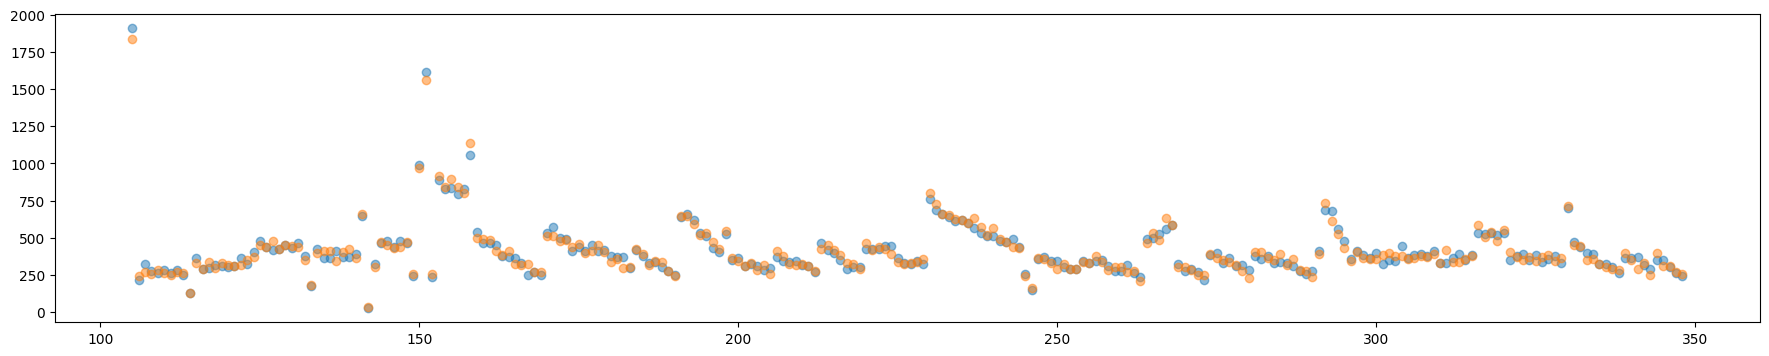

In [60]:
idx = network.populations["HL23PYR"].cells[8].get_rand_idx_area_and_distribution_norm(nidx=100000, section = ['apic'],
                                                   fun=uniform_rv,
                                                   funargs=dict(loc=-1975.0, scale= 1975.0))
idx2 = network.populations["HL23PYR"].cells[9].get_rand_idx_area_and_distribution_norm(nidx=100000, section = ['apic'],
                                                   fun=uniform_rv,
                                                   funargs=dict(loc=-1975.0, scale= 1975.0))

Fig = plt.figure(figsize=(22,4))
a, b = np.unique(idx, return_counts=True)
plt.plot(a, b, 'o', alpha = 0.5)
a, b = np.unique(idx2, return_counts=True)
plt.plot(a, b, 'o', alpha = 0.5)
# plt.xlim(104,110)
# plt.hist(idx2, alpha = 0.5, bins=550);
# plt.xlim(104,120)
# plt.ylim(8000,13000)
# np.unique(idx), np.unique(idx2)

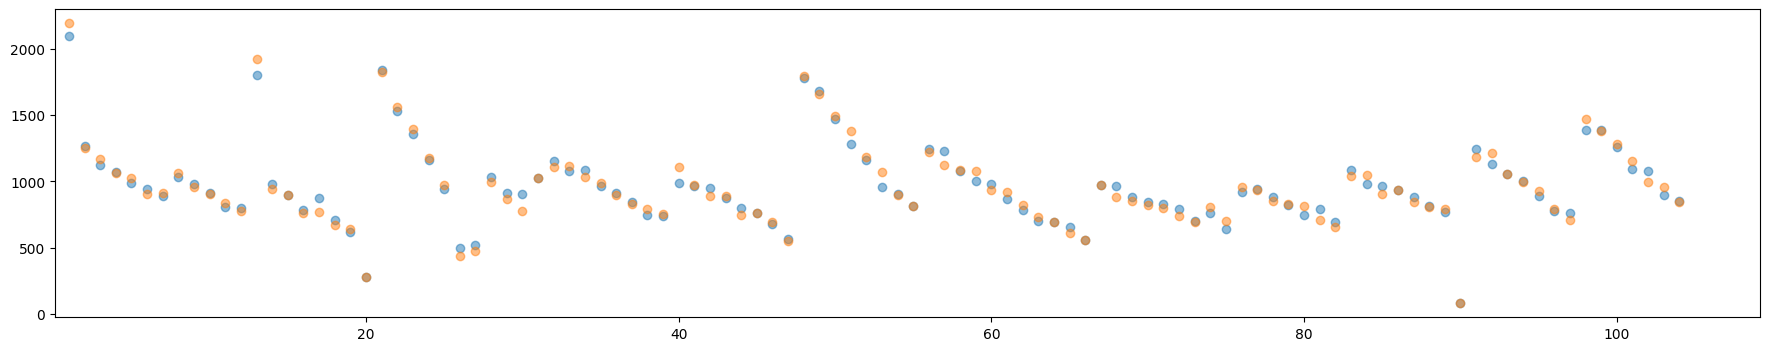

In [63]:
idx = network.populations["HL23PYR"].cells[8].get_rand_idx_area_and_distribution_norm(nidx=100000, section = ['dend'],
                                                   fun=halfnorm_rv,
                                                   funargs=dict(loc=-1975.0, scale= 1975.0))
idx2 = network.populations["HL23PYR"].cells[9].get_rand_idx_area_and_distribution_norm(nidx=100000, section = ['dend'],
                                                   fun=halfnorm_rv,
                                                   funargs=dict(loc=-1975.0, scale= 1975.0))
Fig = plt.figure(figsize=(22,4))
a, b = np.unique(idx, return_counts=True)
plt.plot(a, b, 'o', alpha = 0.5)
plt.xlim(0.10)
a, b = np.unique(idx2, return_counts=True)
plt.plot(a, b, 'o', alpha = 0.5)
# plt.xlim(0,10)